# Hands-On Lab: 5G Architecture Modeling with Python

**Monica Joya**

**ITAI 4370: AI in 5G and 6G Communications and ORAN Networks**

## Objective

In this lab I used the provided code to model the three 5G service types as network slices, each with its own quality-of-service needs, then shared a fixed pool of resources among them with a simple priority-weighted algorithm and plotted the result.

**Note on the starter code (my one change):** the provided data-generation loop placed the `data.append(...)` outside the inner loop, so it recorded only one demand value per slice instead of one per connection. I moved that line inside the inner loop so every connection's demand is recorded, which is what the step is meant to do. Everything else is the starter code as given.

## 1. Setup and Synthetic Data

Each slice is defined by its latency, bandwidth, and number of connections. URLLC is ultra-reliable low-latency, eMBB is high-bandwidth mobile broadband, and mMTC is many low-power devices. I generate a random bandwidth demand for each connection in each slice.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

np.random.seed(42)

# Slice requirements (latency, bandwidth, connections)
slices = {
    "URLLC": {"latency": 1,   "bandwidth": 20, "connections": 30},
    "eMBB":  {"latency": 10,  "bandwidth": 50, "connections": 40},
    "mMTC":  {"latency": 100, "bandwidth": 5,  "connections": 200}
}

# Generate synthetic demand: one random demand per connection
data = []
for s, req in slices.items():
    for i in range(req["connections"]):
        demand = np.random.randint(1, req["bandwidth"] + 1)
        data.append([s, demand])          # moved inside the inner loop (my fix)

df = pd.DataFrame(data, columns=["Slice", "Demand"])
print("Total connections generated:", len(df))
print("\nConnections and total demand per slice:")
print(df.groupby("Slice").agg(connections=("Demand", "size"),
                              total_demand=("Demand", "sum")))
print("\nFirst few rows:")
print(df.head())

Total connections generated: 270

Connections and total demand per slice:
       connections  total_demand
Slice                           
URLLC           30           322
eMBB            40           965
mMTC           200           569

First few rows:
   Slice  Demand
0  URLLC       7
1  URLLC      20
2  URLLC      15
3  URLLC      11
4  URLLC       8


## 2. Resource Allocation Algorithm

A simple proportional allocation: sum each slice's demand, weight it by priority (URLLC highest, mMTC lowest), then normalize the weighted demand so the totals fit the fixed pool of 500 units.

In [2]:
total_resources = 500        # total available units
allocation = {}

# Priority weights: URLLC > eMBB > mMTC
weights = {"URLLC": 3, "eMBB": 2, "mMTC": 1}

for s in slices:
    slice_demand = df[df["Slice"] == s]["Demand"].sum()
    allocation[s] = slice_demand * weights[s]

# Normalize to the total resource pool
total_weighted = sum(allocation.values())
for s in allocation:
    allocation[s] = round((allocation[s] / total_weighted) * total_resources)

print("Allocated resources (out of 500 units):")
for s, a in allocation.items():
    print(f"  {s:6s}: {a}")

Allocated resources (out of 500 units):
  URLLC : 139
  eMBB  : 278
  mMTC  : 82


## 3. Visualization

The bar chart shows how the 500 units are split across the three slices.

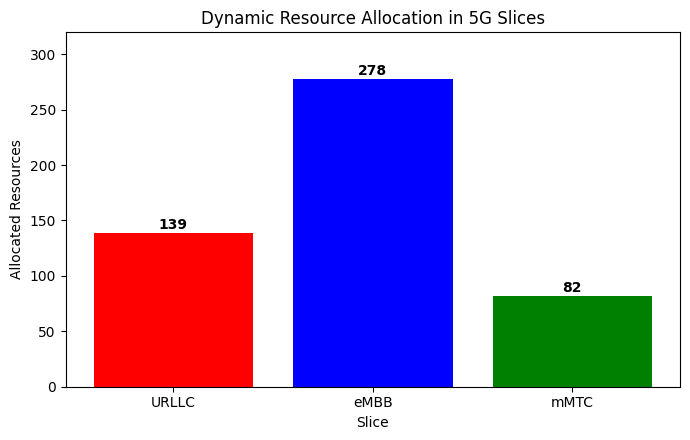

In [3]:
plt.figure(figsize=(7, 4.5))
bars = plt.bar(allocation.keys(), allocation.values(), color=['red', 'blue', 'green'])
plt.title("Dynamic Resource Allocation in 5G Slices")
plt.xlabel("Slice")
plt.ylabel("Allocated Resources")
# label each bar with its value
for b, v in zip(bars, allocation.values()):
    plt.text(b.get_x() + b.get_width()/2, v + 3, str(v), ha="center", fontweight="bold")
plt.ylim(0, max(allocation.values()) * 1.15)
plt.tight_layout()
plt.show()

## Summary

The allocation reflects both demand and priority. eMBB draws the largest share because it combines high per-connection bandwidth with a strong weight, URLLC takes a solid share from its top priority despite fewer connections, and mMTC receives the smallest share since its many devices each ask for very little and it carries the lowest weight. This mirrors how a real 5G network hands the larger slice of limited resources to priority, latency-sensitive traffic while keeping every slice within the total capacity available.